# A Simple Brownian Motion Notebook
### by Patrick Salim
#### May 2026

## Section 1: Standard Brownian Motion
In this section, we shall make use of concepts from basic probability theory and real analysis to construct a standard Brownian motion without drift. A Brownian Motion is a martingale, which is a stochastic process adapted to a filtration, wherein the conditional expectation of the stochastic process at a later time given the information at an earlier time is exactly the same as the expectation at that earlier time, i.e., the expectation is always the same. Colloquially, this is a "fair game". In financial mathematics, running many simulations of such a process is a method of option-pricing, such a method is understood to be a Monte-Carlo simulation. The following definition suffices as an introduction.

**Definition 1.** Let $(\Omega,\mathcal{F},\mathbb{P})$ be a probability space. Suppose for each $\omega \in \Omega$, there exists continuous functions $W(t)$ for some nonnegative $t$ that satisfies $W(0)=0$, that depends on $\omega$, and that each $W(t)$ is $\mathcal{F}(t)$-measurable. Then $W(t)$ is a Brownian motion, if it has the following properties:
1. For partitions $0=t_0<t_1<...<t_m$, the increments $W(t_n)-W(t_{n-1})$ for all $n \in \{1,2,...,m\}$ are independent and,
2. Each of these increments is normally distributed with expectation zero and variance equal to the length of the increment.

Indeed, this implies the increments are i.i.d if the length of each disjoint increment is equal.

We can now construct a Brownian motion by writing a recursive relation $W(t_{n+1})=W(t_n)+X_{n+1}\sqrt{t_{n+1}-t_n}$, where every $X_{n}$ is a normally distributed sample with mean zero and variance one. This ensures that the expectation of an increment is always zero and that its variance is always its length.

To apply this to code, we make use of the NumPy library to generate $k$ paths. We start by sampling $k \times N$ draws, where $N$ is the time steps, from a standard normal distribution. In addition to this, we shall also import Matplotlib, Pandas, and Seaborn.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from math import sqrt, exp
from random import random, gauss

We shall write a function that plots standard Brownian motion.

In [2]:
def plot_std_brownian(paths,points):

    # First, we define a random number generator via NumPy.
    rng = np.random.default_rng(42)

    # We shall assume no drift (mu=0) and variance one.
    mu, sigma = 0.0, 1.0

    # We shall now utilise the random number generator for the normally distributed sample X.
    X = rng.normal(mu, sigma, (paths, points))

    # For the purpose of this project we shall choose $t_m=1$, and for the increments to be of equal length.
    interval = [0.0, 1.0]
    dt = (interval[1] - interval[0]) / (points - 1)
    t_axis = np.linspace(interval[0], interval[1], points)
    W = np.zeros((paths, points))

    # Recursive relation
    for t in range(points - 1):
        real_t = t + 1
        W[:, real_t] = W[:, real_t - 1] + X[:, real_t] * sqrt(dt)

    # Now to plot the standard Brownian motion.
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    for path in range(paths):
        ax.plot(t_axis, W[path, :])
    ax.set_title("Standard Brownian motion")
    ax.set_xlabel("Time")
    ax.set_ylabel("Asset Value")
    plt.show()

    # Kernel Density Estimate at final Time=1
    # We first create a Pandas DataFrame of the sample path values at Time = 1.0.
    final_values = pd.DataFrame({'final_values': W[:, -1]})
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    sns.kdeplot(data=final_values, x='final_values', fill=True, ax=ax)
    ax.set_title("Kernel density estimate of the asset price at Time = 1.0")
    ax.set_ylim(0.0, 0.5)
    ax.set_xlabel('Asset price at Time = 1.0')
    plt.show()

    # Sample mean and standard deviation of sample at Time=1
    print(final_values.mean(), final_values.std())

By the Strong Law of Large Numbers (Kolmogorov's Law), the sample mean $\bar{W}(t)$ shall converge almost surely to the expectation (in this case, zero) as t goes to infinity. That is, $\mathbb{P}\{\omega \in \Omega \mid \bar{W}(t) \nrightarrow 0\}=0$. This is why the bulk of the paths are denser around the asset value of zero even at Time = 1.0, as per the usual behaviour of standard Brownian motion with no drift.

Indeed, by the Central Limit Theorem, the distribution of this Brownian motion shall approach normal distribution. We may see this by using Kernel Density Estimate (KDE) from Seaborn.

We may now specify the quantity of paths and time steps per path, which for the purpose of this project shall be 50 and 1000, respectively, for this example.

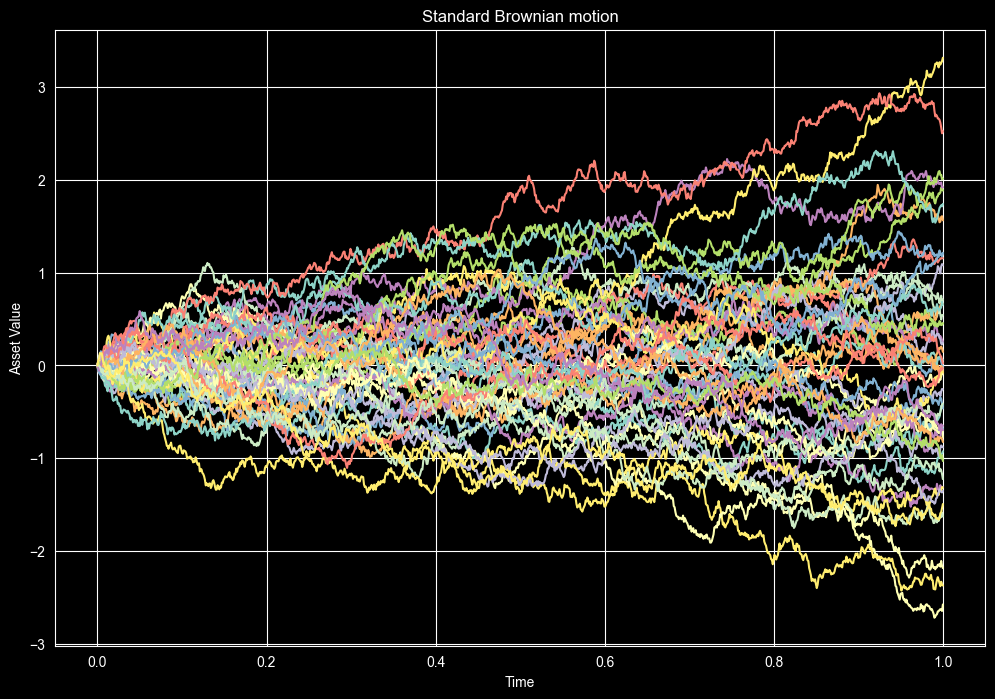

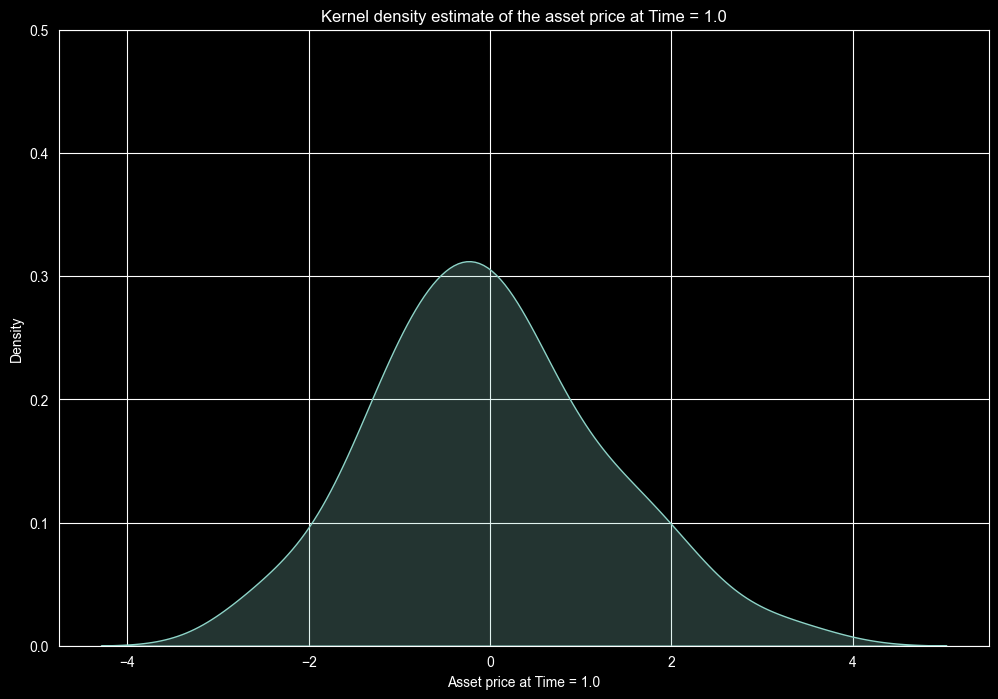

final_values   -0.013798
dtype: float64 final_values    1.252174
dtype: float64


In [3]:
plot_std_brownian(paths=50, points=1000)

This approaches standard normal distribution, as indicated by the sample mean and volatility (standard deviation).

## Section 2: Brownian Motion with Drift
Now we shall concern ourselves with standard Brownian motion with constant drift and volatility, call this $Y(t)$. To do this, we shall write $Y(t_{n+1})=Y(t_n)+\mu(t_{n+1}-t_n)+\sigma X_{n+1}\sqrt{t_{n+1}-t_n}$, where again every $X_{n}$ is a normally distributed sample with mean zero and variance one, $\mu$ is the constant drift, and $\sigma$ is the volatility. Again, we shall choose the increments $Y(t_n)-Y(t_{n-1})$ for all $n \in \{1,2,...,m\}$ to be of length one so that they are i.i.d.

Just to show that this recursive relation satisfies the definition of Brownian motion, if we take expectation of any increment, then $\mathbb{E}[Y(t_{n+1})-Y(t_n)]=\mu$. And, if we take the second moment of any increment, we shall obtain $\mathbb{E}[(Y(t_{n+1})-Y(t_n))^2]=\mu^2 + \sigma^2$. Hence, if we subtract from the second moment $\mathbb{E}[Y(t_{n+1})-Y(t_n)]^2=\mu^2$, then we shall get the variance $\mathrm{Var}[Y(t_{n+1})-Y(t_n)]=\sigma^2$.

In [4]:
def plot_drift_brownian(paths,points,drift,volatility):

    # Random number generator
    rng = np.random.default_rng(42)

    # The normally distributed sample X.
    mu, sigma = 0.0, 1.0
    X = rng.normal(mu, sigma, (paths, points))

    # For the purpose of this project we shall choose $t_m=1$, and for the increments to be of equal length.
    interval = [0.0, 1.0]
    dt = (interval[1] - interval[0]) / (points - 1)
    t_axis = np.linspace(interval[0], interval[1], points)
    Y = np.zeros((paths, points))

    # Recursive relation
    for t in range(points - 1):
        real_t = t + 1
        Y[:, real_t] = Y[:, real_t - 1] + drift * dt + volatility * X[:, real_t] * sqrt(dt)

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    for path in range(paths):
        ax.plot(t_axis, Y[path, :])
    ax.set_title("Brownian motion with constant drift and volatility")
    ax.set_xlabel("Time")
    ax.set_ylabel("Asset Value")
    plt.show()

    # KDE at final Time=1
    final_values_drift = pd.DataFrame({'final_values_drift': Y[:, -1]})
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    sns.kdeplot(data=final_values_drift, x='final_values_drift', fill=True, ax=ax)
    ax.set_title("Kernel density estimate of sample with drift at Time = 1.0")
    ax.set_ylim(0.0, 0.15)
    ax.set_xlabel('Asset price at Time = 1.0')
    plt.show()

    # Drift and volatility of sample at Time=1
    print(final_values_drift.mean(), final_values_drift.std())

For the purpose of this project, we shall choose the drift to be 4 and volatility to be 3. We now plot the simulation.

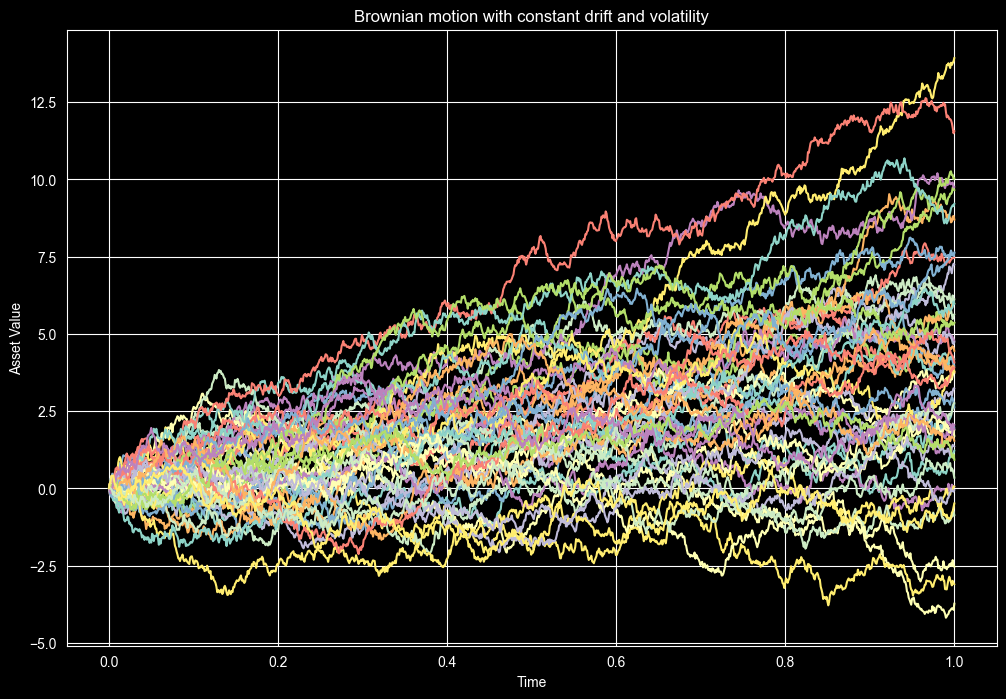

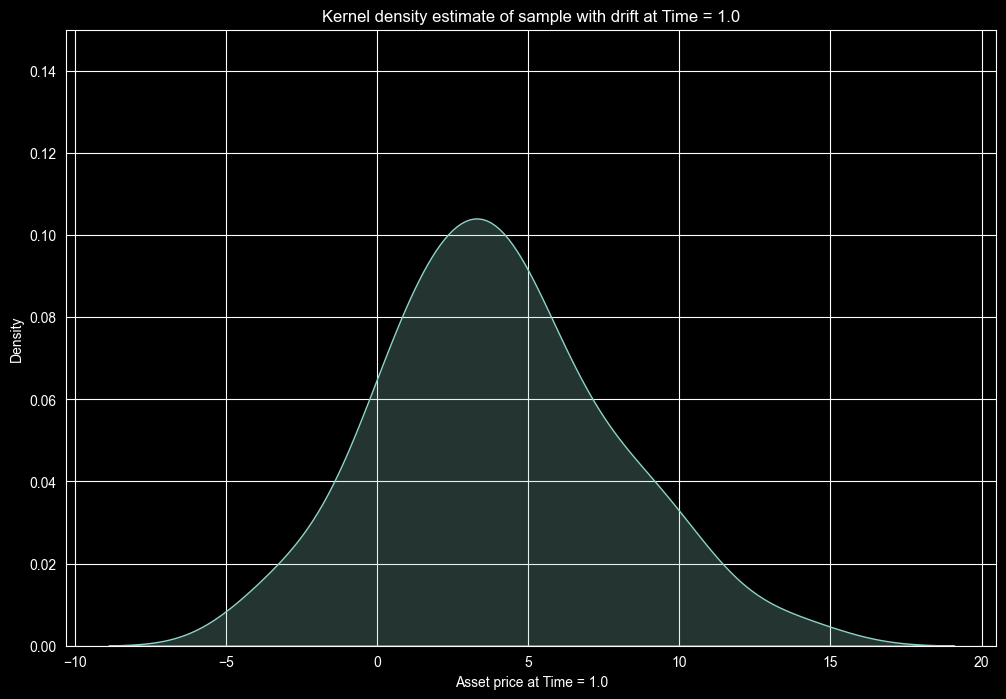

final_values_drift    3.958607
dtype: float64 final_values_drift    3.756521
dtype: float64


In [5]:
plot_drift_brownian(paths=50, points=1000, drift=4, volatility=3)

As shown above, the mean and standard deviation at Time=1 is "close" to the drift and volatility that we have chosen for this simulation.

## Section 3: 3D Brownian Motion
We may even extend our coordinate system to three dimensions to construct the 3D standard Brownian motion. To do this, we write the recursive relations:

$W_x(t_{n+1})=W_x(t_n)+X_{n+1}\sqrt{t_{n+1}-t_n}$

$W_y(t_{n+1})=W_y(t_n)+X_{n+1}\sqrt{t_{n+1}-t_n}$

$W_z(t_{n+1})=W_z(t_n)+X_{n+1}\sqrt{t_{n+1}-t_n}$

where every $X_{n}$ is a normally distributed sample with mean zero and variance one. And we code this as follows.


In [6]:
def plot_3d_std_bm(points):

    # Assume no drift (mu=0) and variance one.
    mu, sigma = 0.0, 1.0

    # For the purpose of this project we shall choose the time t in [0,1], and for the increments to be of equal length.
    dt = 1/points
    data = []
    W_x, W_y, W_z = 0, 0, 0

    # Recursive relation
    for t in range(points):
       dx = gauss(mu, sigma*sqrt(dt))
       dy = gauss(mu, sigma*sqrt(dt))
       dz = gauss(mu, sigma*sqrt(dt))
       W_x, W_y, W_z = W_x + dx, W_y + dy, W_z + dz
       data.append((W_x, W_y, W_z))

    data = np.array(data)

    # Now to plot the standard Brownian motion.
    plt.figure(figsize=(12, 8))
    ax = plt.axes(projection='3d')
    ax.plot3D(data[:, 0], data[:, 1], data[:, 2], linewidth=0.5)
    ax.plot3D(data[0, 0], data[0, 1], data[0, 2], marker='o', color='red')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.set_title('3D standard Brownian motion')
    plt.show()

Now we shall run the code with 1000 points.

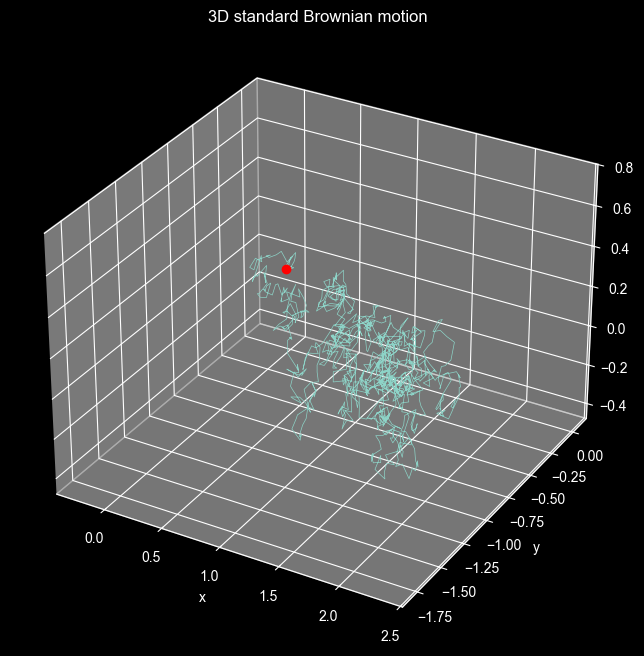

In [7]:
plot_3d_std_bm(points=1000)

## Section 4: Geometric Brownian Motion
One standard asset-price model used in the Black-Scholes-Merton option-pricing formula is the geometric Brownian motion. Let $\alpha$ and $\sigma > 0$ be real constants, then we define the geometric Brownian motion as: $S(t)=S(0) \mathrm{exp} \{ \sigma W(t) + (\alpha - \frac{1}{2} \sigma^2)t \}$. We may let $\beta = \alpha - \frac{1}{2} \sigma^2$, so that $S(t)=S(0) \mathrm{exp} \{ \sigma W(t) + \beta t \}$. And we may implement this into code.

In [8]:
def plot_geo_bm(annual_trading_days,initial_stock_price,volatility,alpha):

    # We shall again assume uniform increments
    dt = 1/annual_trading_days
    S = initial_stock_price
    sigma = volatility
    a = alpha

    # The recursive relation
    data = [(0, S)]
    for t in range(1, annual_trading_days):
        ratio = exp(sigma * gauss(0, sqrt(dt))) * exp((alpha - (1/2)*sigma**2)*dt)
        S = S * ratio
        data.append((dt*t, S))

    data = np.array(data)

    # The plot
    plt.figure(figsize=(12, 8))
    plt.plot(data[:, 0], data[:, 1], linewidth=0.5)
    plt.xlabel('Time')
    plt.ylabel('Stock price in IDR')
    plt.ylim([0, max(data[:,1]+10)])
    plt.title('Geometric Brownian motion')
    plt.show()

We shall now execute this function to run a simulation of stock prices over the trading days in a year, which in this example shall be every day, with the initial price $S(0)$ being 100 IDR, volatility $\sigma=1.5$, and $\alpha=2.5$.

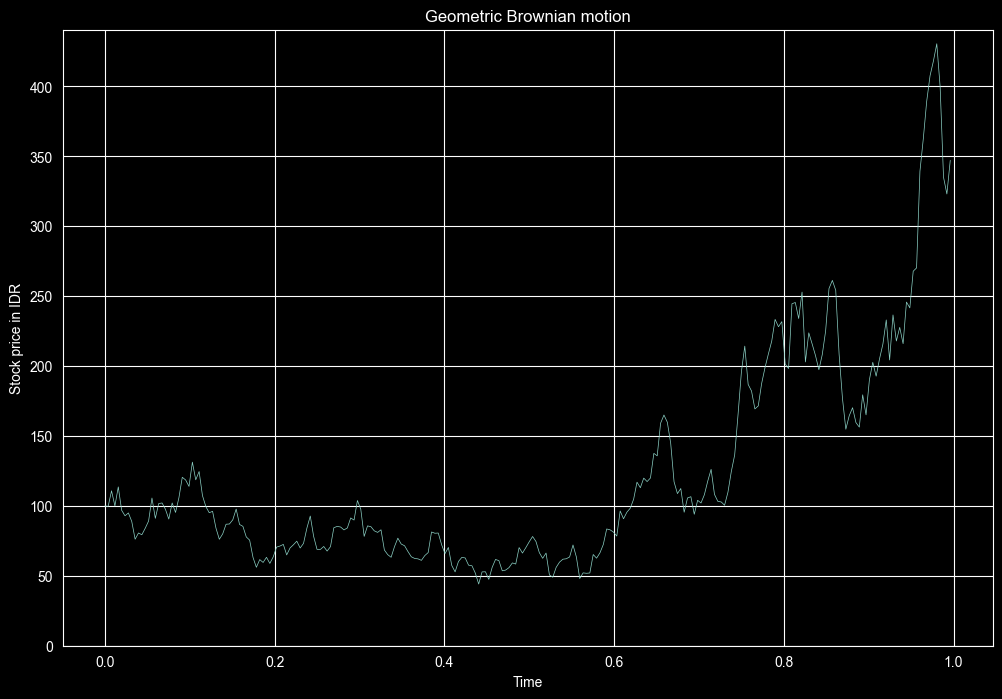

In [9]:
plot_geo_bm(annual_trading_days=252, initial_stock_price=100, volatility=1.5, alpha=2.5)

## Section 4: First Passage Time and Max of Brownian Motion to Date

**Definition 2.** Let $m$ be a real number. We define the first passage time to barrier $m$ as $\tau_m = \mathrm{min} \{t \geq 0 \mid W(t)=m \}$. This is the first time a Brownian motion reaches the barrier m. If the Brownian motion never reaches m, then we set $\tau_m = \infty$.

We shall now fix a positive level $m$ and a positive time $t$. What happens when Brownian motion reaches level $m$ prior to time $t$, but is at a level $w$ below $m$ at time $t$? If we draw a reflected path of the Brownian motion after $\tau_m$, we shall see that due to the symmetry of Brownian motion, we may obtain the reflection equality: $\mathbb{P}\{\tau_m \leq t, W(t) \leq m\} = \mathbb{P}\{W(t) \geq 2m-w\}, w \leq m, m > 0$.

To see that this is true, we may code the following.

In [10]:
def plot_drift_brownian(points,drift,volatility,barrier):
    # For the purpose of this project we shall choose t in [0,1], and for the increments to be of equal length.
    dt = 1/points
    w = 0

    # Track both the original and reflected data
    data_original = [(0, w)]
    data_reflected = [(0, w)]

    # Flag to check if the path has hit the barrier
    hit_barrier = False

    # Recursive relation
    for t in range(1, points + 1):
        # The mean of the increment is drift * dt, std dev is volatility * sqrt(dt)
        dw = gauss(drift * dt, volatility * sqrt(dt))
        w = w + dw

        # Check if we crossed the barrier (assuming an upper barrier where w >= barrier)
        if not hit_barrier and w >= barrier:
            hit_barrier = True

        # Apply the reflection principle W_ref = 2m - W if the barrier was hit
        if hit_barrier:
            w_ref = 2 * barrier - w
        else:
            w_ref = w

        # Append the correct time step and the updated values (without adding dw again)
        data_original.append((dt * t, w))
        data_reflected.append((dt * t, w_ref))

    data_original = np.array(data_original)
    data_reflected = np.array(data_reflected)

    # The plot
    plt.figure(figsize=(12, 8))

    # Plot original path
    plt.plot(data_original[:, 0], data_original[:, 1], label='Original Brownian motion', linewidth=1, color='blue', alpha=0.5)

    # Plot reflected path (will map directly over the original until the barrier is hit)
    if hit_barrier:
        plt.plot(data_reflected[:, 0], data_reflected[:, 1], label='Reflected path', linewidth=1.5, color='red', linestyle='--')
        plt.axhline(y=barrier, color='green', linestyle=':', linewidth=2, label=f'Barrier (USD {barrier})')

    plt.xlabel('Time')
    plt.ylabel('Stock price in USD')

    # Dynamically adjust y-limits to fit both paths nicely without clipping negatives
    y_max = max(np.max(data_original[:, 1]), np.max(data_reflected[:, 1])) + 10
    y_min = min(np.min(data_original[:, 1]), np.min(data_reflected[:, 1])) - 10
    plt.ylim([y_min, y_max])

    plt.title('Brownian motion with reflection principle')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

The reflected path of Brownian motion can be written as $W_{ref}(t) = 2m - W(t)$. We now execute an example wherein we have 1000 points, drift 10, volatility 5 and barrier 3 USD.

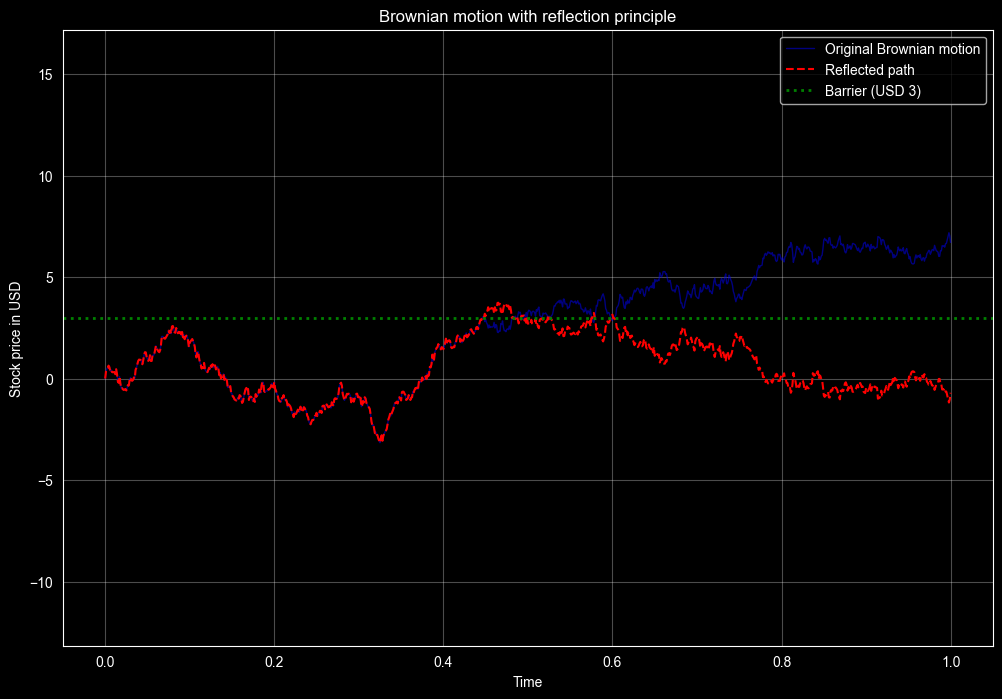

In [11]:
plot_drift_brownian(points=1000, drift=10, volatility=5, barrier=3)

Indeed, the blue trajectory looks like the value of the USD rising, and the red trajectory is the value of the IDR falling #gallowshumour. Hence, we may now obtain the distribution for the first passage time $\tau_m$.

**Theorem 3.** For all nonzero $m$, the random variable $\tau_m$ has cumulative distribution function:

$\mathbb{P}\{\tau_m \leq t\} = \frac{2}{\sqrt{2 \pi t}} \int_{|m|}^{\infty} e^{-\frac{x^2}{2t}} \, dx, t \geq 0$.

**Proof.** First, we consider the case wherein $m > 0$. If we let $w = m$, then $\mathbb{P}\{\tau_m \leq t, W(t) \leq m\} = \mathbb{P}\{W(t) \geq m\}$. On the other hand, if $W(t) \geq m$, then $\tau_m \leq t$. Hence, $\mathbb{P}\{\tau_m \leq t, W(t) \geq m\} = \mathbb{P}\{W(t) \geq m\}$. If we add these equalities, then we obtain the cumulative distribution function for $\tau_m$:

$\mathbb{P}\{\tau_m \leq t\} = \mathbb{P}\{\tau_m \leq t, W(t) \leq m\} + \mathbb{P}\{\tau_m \leq t, W(t) \geq m\} = 2 \mathbb{P}\{W(t) \geq m\} = \frac{2}{\sqrt{2 \pi t}} \int_{m}^{\infty} e^{-\frac{x^2}{2t}} \, dx$.

Where the last equality holds because Brownian motion $W(t)$ is a normally distributed random variable with mean 0 and variance $t$. If $m < 0$, then $\tau_m$ and $\tau_{|m|}$ have the same distribution due to symmetry. Hence, we have the equality stated in **Theorem 3**.

We now introduce another stochastic process used for pricing barrier options:

**Definition 4.** The maximum to date for Brownian motion is $M(t) = \max_{s \in [0,t]} W(s)$.

In code, this looks like the following.

In [12]:
def plot_maxtd_bm(points,drift,volatility):

    # For the purpose of this project we shall choose t in [0,1], and for the increments to be of equal length.
    dt = 1/points
    data = []
    w = 0

    # Recursive relation
    for t in range(1, points + 1):
        dw = gauss(drift * dt, volatility * sqrt(dt))
        w = w + dw
        data.append((dt * t, w))

    data = np.array(data)
    data_m = np.maximum.accumulate(data)

    # The plot
    plt.figure(figsize=(12, 8))

    # Plot original path
    plt.plot(data_m[:, 0], data_m[:, 1], linewidth=1, color='blue')
    plt.xlabel('Time')
    plt.ylabel('Stock price')
    plt.title('Max of Brownian motion to date')
    plt.show()

Here we shall simulate 1000 points, let drift be 0, and volatility 0.2. This adapted stochastic process happens to also be a submartingale.

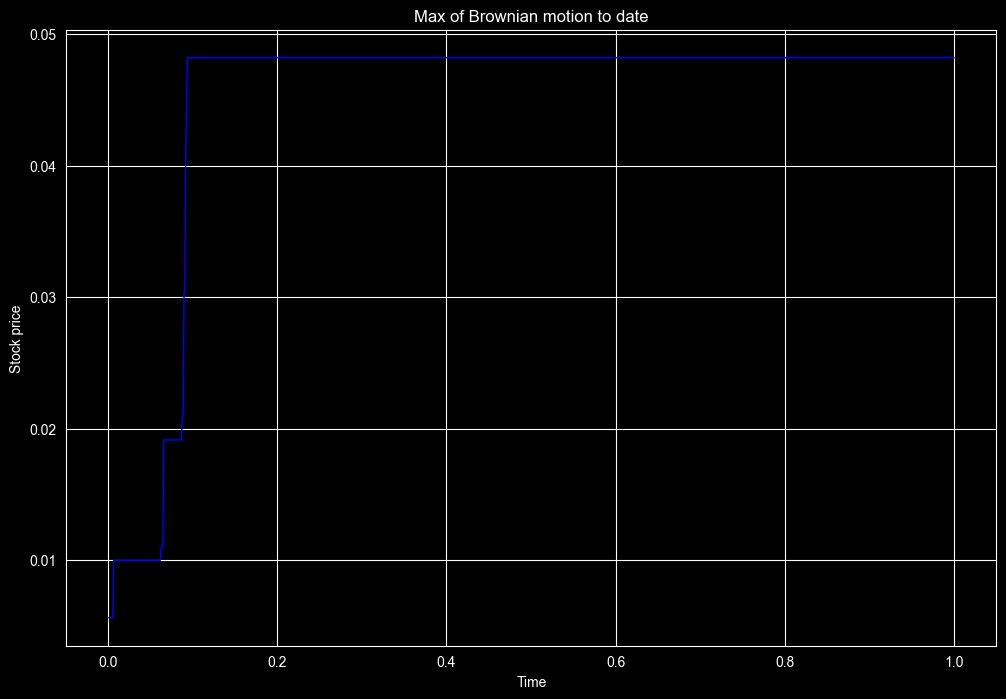

In [13]:
plot_maxtd_bm(points=1000, drift=0, volatility=0.2)

From the proof of **Theorem 3**, we know that for positive $m$, we have $M(t) \geq m$ if and only if $\tau_m \leq t$. Hence, we may write the reflection equality as: $\mathbb{P}\{M(t) \geq m, W(t) \leq m\} = \mathbb{P}\{W(t) \geq 2m-w\}, w \leq m, m > 0$. This allows us to obtain the joint distribution of $M(t)$ and $W(t)$.

**Theorem 5.** For positive $t$, the joint density of $M(t)$ and $W(t)$ is:

$f_{M(t),W(t)}(m,w) = \frac{2(2m-w)}{t \sqrt{2 \pi t}} e^{- \frac{(2m-w)^2}{2t}}, w \leq m, m > 0$.

**Proof.** We know that:

$\mathbb{P}\{M(t) \geq m, W(t) \leq m\} = \int_{m}^{\infty} \int_{- \infty}^{w} f_{M(t),W(t)}(x,y) \, dy \, dx$,

and

$\mathbb{P}\{W(t) \geq 2m-w\} = \frac{1}{\sqrt{2 \pi t}} \int_{2m-w}^{\infty} e^{-\frac{z^2}{2t}} \, dz$.

Combining these two we get:

$\int_{m}^{\infty} \int_{- \infty}^{w} f_{M(t),W(t)}(m,w) \, dy \, dx = \frac{1}{\sqrt{2 \pi t}} \int_{2m-w}^{\infty} e^{-\frac{z^2}{2t}} \, dz$.

We differentiate first with respect to $m$ to obtain:

$- \int_{- \infty}^{w} f_{M(t),W(t)}(m,y) \, dy = - \frac{2}{\sqrt{2 \pi t}} e^{-\frac{(2m-w)^2}{2t}}$.

We next differentiate with respect to $w$ to see that:

$- f_{M(t),W(t)}(m,w) = - \frac{2(2m-w)}{t \sqrt{2 \pi t}} e^{- \frac{(2m-w)^2}{2t}}$.

We are done.

When simulating Brownian motion to price exotic options, quantitative analysts often simulate the value of the Brownian motion at some time $T > 0$ and then simulate the maximum of the Brownian motion between times 0 and $t$. This second step often requires them to make use of the distribution of the submartingale $M(t)$ on $[0,t]$ conditioned on the value of $W(t)$. The following corollary provides this conditional distribution.

**Corollary 6.** The conditional distribution of $M(t)$ given $W(t)=w$  is:

$f_{M(t) \mid W(t)}(m \mid w) = \frac{2(2m-w)}{t} e^{- \frac{2m(m-w)}{t}}, w \leq m, m > 0$.

**Proof.** By Bayes' Theorem, the conditional density is the joint density divided by the marginal density of the conditioning random variable. Thus,

$f_{M(t) \mid W(t)}(m \mid w) = \frac{f_{M(t),W(t)}(m,w)}{f_{W(t)}(w)} = \frac{2(2m-w)}{t \sqrt{2 \pi t}} \sqrt{2 \pi t} e^{- \frac{(2m-w)^2}{2t} + \frac{w^2}{2t}} = \frac{2(2m-w)}{t} e^{- \frac{2m(m-w)}{t}}$

We can code this to visualise.

In [14]:
def conditional_pdf(m, w, t):
    # Calculates the conditional PDF of M(t) given W(t)=w, i.e., f(m|w) = (2(2m-w)/t) * exp(-2m(m-w)/t)
    return (2 * (2 * m - w) / t) * np.exp(-2 * m * (m - w) / t)

def plot_2d_distribution(t, w_values, m_max=5.0):
    # Generates a 2D line plot for the conditional distribution given specific values of W(t) = w.
    plt.figure(figsize=(10, 6))

    for w in w_values:
        # Constraint: The max to date (m) must be >= 0 AND >= W(t)
        m_min = max(0.0, w)

        # Create an array of m values from the minimum valid m up to m_max
        # Adding a tiny offset to avoid evaluating exactly at m=0 if w<0
        m = np.linspace(m_min + 0.001, m_max, 500)

        # Calculate density
        pdf = conditional_pdf(m, w, t)

        plt.plot(m, pdf, label=f'$W(t) = {w}$')

    plt.title(f'Conditional Distribution of $M(t)$ given $W(t)$, $t={t}$')
    plt.xlabel('Maximum value $m$')
    plt.ylabel('Density $f_{M(t)|W(t)}(m|w)$')
    plt.legend()
    plt.grid(alpha=0.4)
    plt.show()

def plot_3d_surface(t, m_max=5.0, w_min=-3.0, w_max=3.0):
    # Generates a 3D surface plot mapping the density across combinations of m and w.
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Create grid for w and m
    w_vals = np.linspace(w_min, w_max, 100)
    m_vals = np.linspace(0.001, m_max, 100)
    W, M = np.meshgrid(w_vals, m_vals)

    # Initialize the Z (PDF) array with zeros
    Z = np.zeros_like(W)

    # Apply the mathematical constraints: m >= 0 and m >= w
    valid_mask = (M >= 0) & (M >= W)

    # Calculate PDF only where the constraints are met
    Z[valid_mask] = conditional_pdf(M[valid_mask], W[valid_mask], t)
    Z[~valid_mask] = np.nan # Hide invalid regions

    surf = ax.plot_surface(M, W, Z, cmap='viridis', edgecolor='none', alpha=0.9)

    ax.set_title(f'3D Surface of $f_{{M(t)|W(t)}}(m|w)$ at $t={t}$')
    ax.set_xlabel('Maximum $m$')
    ax.set_ylabel('Terminal Value $w$')
    ax.set_zlabel('Density')
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Probability Density')
    plt.show()

Let us fix $t=1$, then:

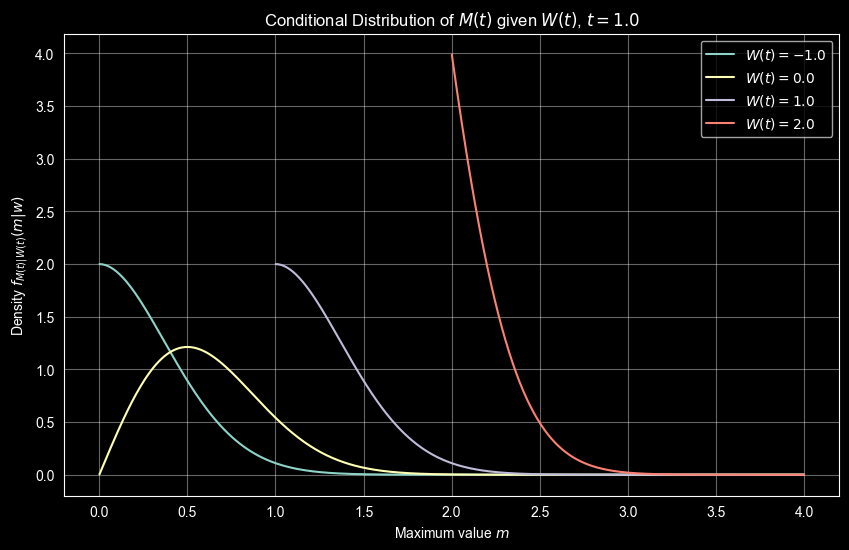

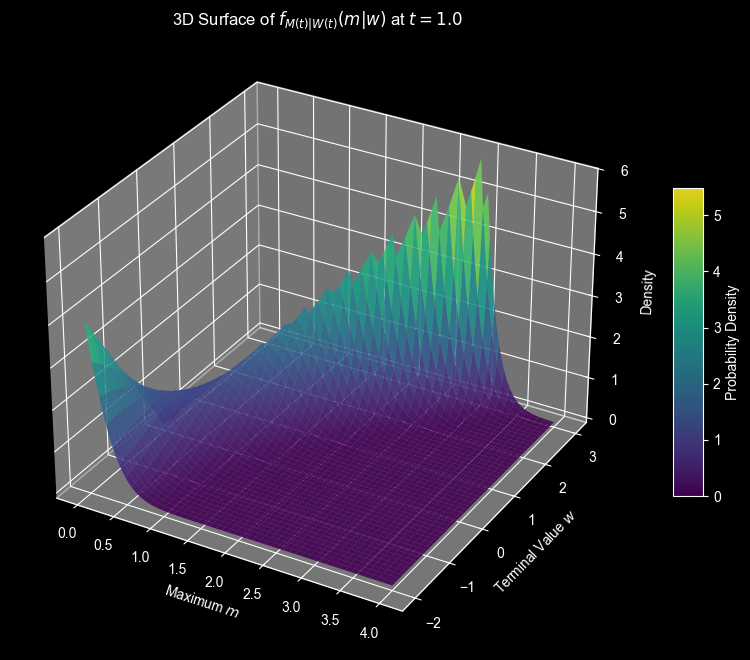

In [15]:
# Plot 2D slices for w = -1, 0, 1, 2
plot_2d_distribution(t=1.0, w_values=[-1.0, 0.0, 1.0, 2.0], m_max=4.0)

# Plot the 3D surface
plot_3d_surface(t=1.0, m_max=4.0, w_min=-2.0, w_max=3.0)

Stay tuned for other projects on my GitHub.